In [98]:
from factor_diffusion_train import FACTOR_NAMES, PREFIX, MODE
from factor_model import FactorModel, load_model
from factor_diffusion_sample import NUM_GENERATE
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [99]:
model = load_model(PREFIX)
test_model = load_model(f"{PREFIX}/test")
print(PREFIX)

model/regression


### Factor Level Evaluation

In [100]:
sampled = np.load(f"{PREFIX}/samples/factor_{MODE}_{NUM_GENERATE}.npy")
print(f"{PREFIX}/samples/factor_{MODE}_{NUM_GENERATE}.npy")

model/regression/samples/factor_DLPM_2048.npy


In [101]:
train = model.F
train = train.drop(columns=['alpha']).values

OOS = test_model.F.drop(columns=['alpha']).values

N_BASELINES = 1
rng = np.random.default_rng(42)
baselines = []

row_idx = rng.choice(train.shape[0], size=len(sampled), replace=True)
label = "Resample"
baselines.append((label, train[row_idx]))

base_colors = ['#17becf']

print(f"OOS: {OOS.shape}  sampled: {sampled.shape}  train: {train.shape}")
print(f"baselines: {N_BASELINES} × {baselines[0][1].shape}")

OOS: (1174, 7)  sampled: (2048, 7)  train: (2738, 7)
baselines: 1 × (2048, 7)


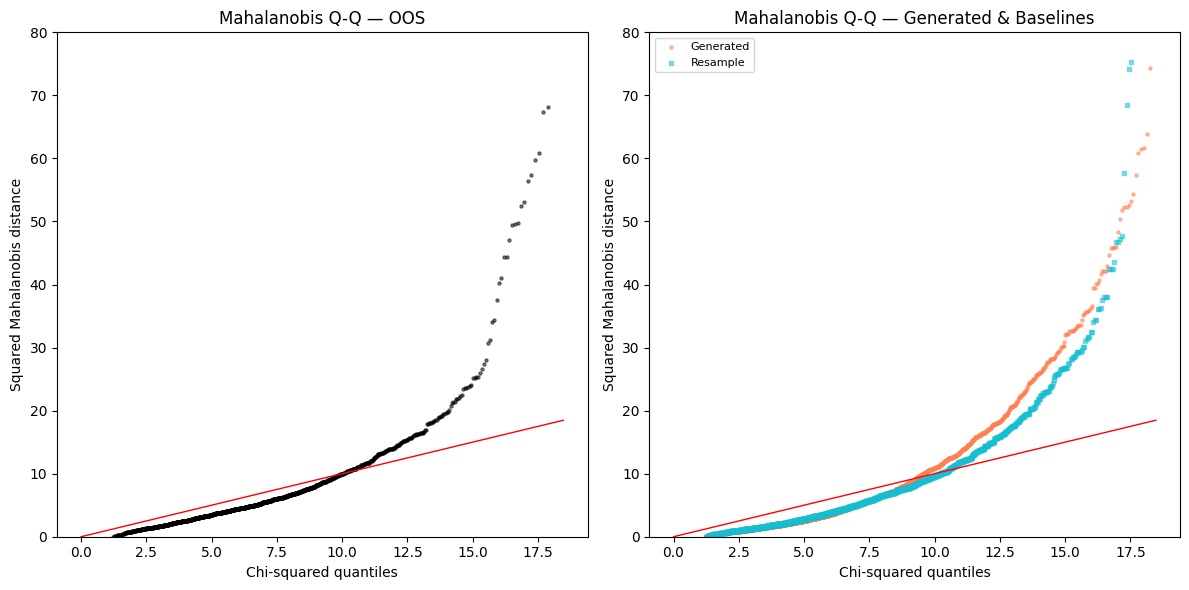

In [102]:
# 2.0 Mahalanobis check
def mahal_d2(X):
    mean = X.mean(axis=0)
    cov  = np.cov(X, rowvar=False)
    diff = X - mean
    return (diff @ np.linalg.inv(cov) * diff).sum(axis=1)

def plot_mahal(ax, X, label, color='steelblue', marker='o', size=5, alpha=0.5):
    p  = X.shape[1]
    d2 = mahal_d2(X)
    qs = stats.chi2.ppf(np.linspace(0.01, 0.99, len(d2)), df=p)
    ax.scatter(qs, np.sort(d2), s=size, alpha=alpha, color=color,
               marker=marker, label=label)
    return qs.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Left panel: OOS
q_max = plot_mahal(ax1, OOS, 'OOS', color='black')
ax1.plot([0, q_max], [0, q_max], color='red', linewidth=1)
ax1.set_ylim(0, 80)
ax1.set_xlabel('Chi-squared quantiles'); ax1.set_ylabel('Squared Mahalanobis distance')
ax1.set_title('Mahalanobis Q-Q — OOS')

# Right panel: Generated + Baselines overlaid
q_max2 = plot_mahal(ax2, sampled, 'Generated', color='coral')
for (bname, bdata), bc in zip(baselines, base_colors):
    q_max2 = max(q_max2, plot_mahal(ax2, bdata, bname, color=bc, marker='s'))
ax2.plot([0, q_max2], [0, q_max2], color='red', linewidth=1)
ax2.set_ylim(0, 80)
ax2.set_xlabel('Chi-squared quantiles'); ax2.set_ylabel('Squared Mahalanobis distance')
ax2.set_title('Mahalanobis Q-Q — Generated & Baselines')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

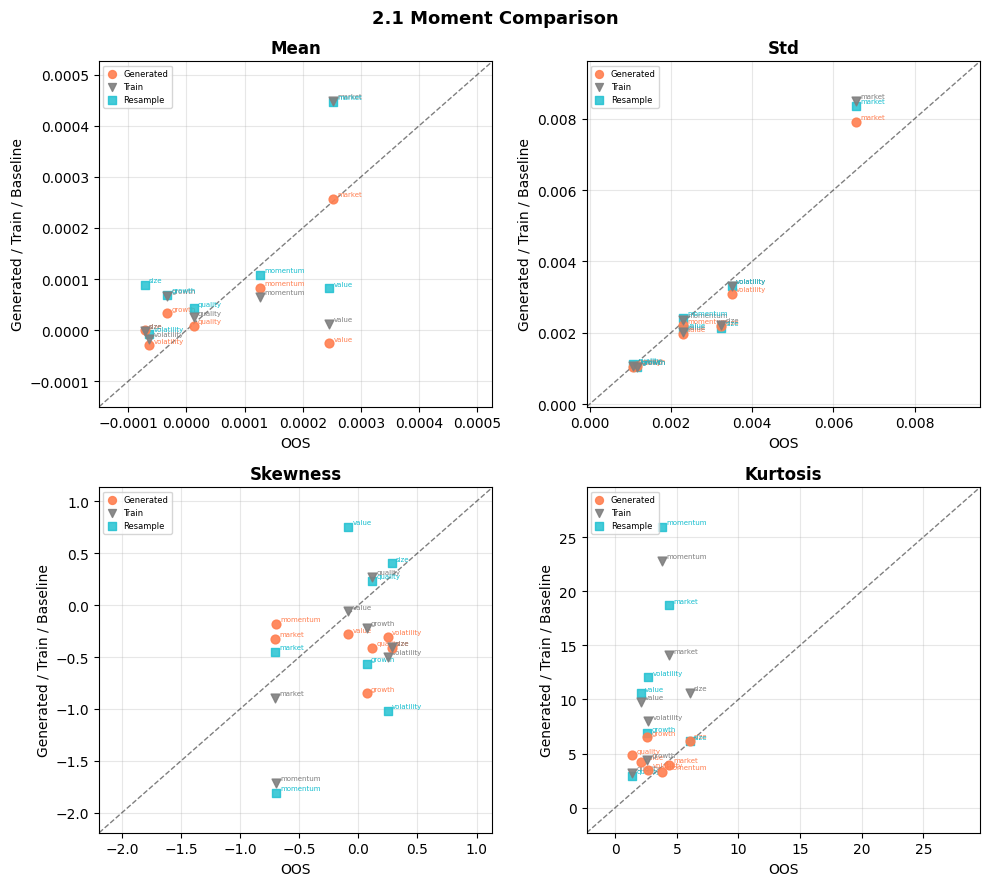

In [103]:
# 2.1 Moment Comparison
def compute_moments(data):
    return [np.mean(data, axis=0), np.std(data, axis=0),
            stats.skew(data, axis=0), stats.kurtosis(data, axis=0)]

m_OOS    = compute_moments(OOS)
m_gen   = compute_moments(sampled)
m_train = compute_moments(train)
m_bases = [(name, compute_moments(data)) for name, data in baselines]
moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']

ANNOT_FS = 5   # annotation font size
LEGEND_FS = 6  # legend font size
PT_SIZE   = 40 # scatter point size

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for idx, (ax, mname) in enumerate(zip(axes.flatten(), moment_names)):
    OOS_m    = m_OOS[idx]
    gen_m   = m_gen[idx]
    train_m = m_train[idx]
    all_y   = [gen_m, train_m] + [bm[idx] for _, bm in m_bases]

    lim = [min(OOS_m.min(), min(y.min() for y in all_y)),
           max(OOS_m.max(), max(y.max() for y in all_y))]
    pad = (lim[1] - lim[0]) * 0.15 or 0.01
    lim = [lim[0] - pad, lim[1] + pad]

    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)

    for vals, color, marker, label in [
        (gen_m,   'coral',    'o', 'Generated'),
        (train_m, '#7f7f7f',  'v', 'Train'),
    ]:
        ax.scatter(OOS_m, vals, color=color, s=PT_SIZE, marker=marker, zorder=4, label=label, alpha=0.9)
        for i, fn in enumerate(FACTOR_NAMES):
            ax.annotate(fn, (OOS_m[i], vals[i]), fontsize=ANNOT_FS,
                        xytext=(3, 2), textcoords='offset points', color=color)

    for (bname, bm), bc in zip(m_bases, base_colors):
        ax.scatter(OOS_m, bm[idx], color=bc, s=PT_SIZE, marker='s', zorder=3, label=bname, alpha=0.8)
        for i, fn in enumerate(FACTOR_NAMES):
            ax.annotate(fn, (OOS_m[i], bm[idx][i]), fontsize=ANNOT_FS,
                        xytext=(3, 2), textcoords='offset points', color=bc)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('OOS'); ax.set_ylabel('Generated / Train / Baseline')
    ax.set_title(mname, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FS, markerscale=0.9, handlelength=1.2)

fig.suptitle('2.1 Moment Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

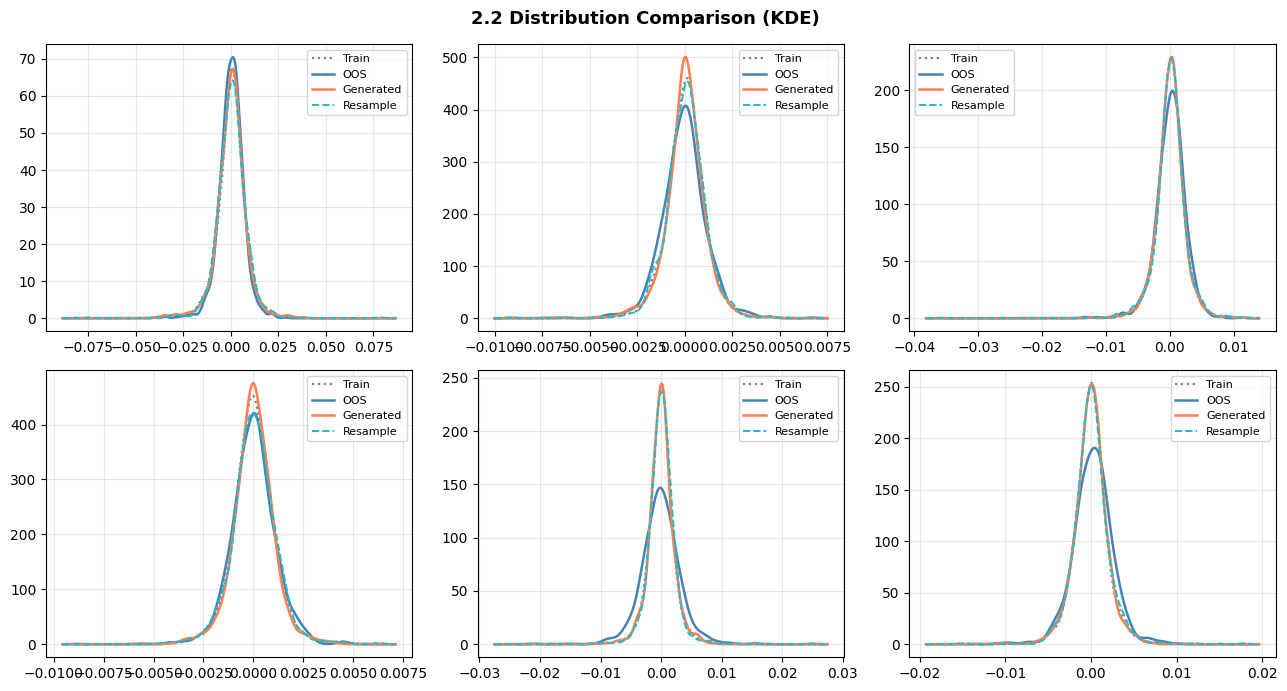

In [104]:
# 2.2 Distribution Comparison (KDE)
from scipy.stats import gaussian_kde

n_factors = len(FACTOR_NAMES)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(n_factors)):
    OOS_vals    = OOS[:, i]
    gen_vals   = sampled[:, i]
    train_vals = train[:, i]

    all_vals = np.concatenate([OOS_vals, gen_vals, train_vals] +
                              [bdata[:, i] for _, bdata in baselines])
    x_min, x_max = all_vals.min(), all_vals.max()
    pad = (x_max - x_min) * 0.05
    x = np.linspace(x_min - pad, x_max + pad, 300)

    for vals, label, color, ls, lw in [
        (train_vals, 'Train',     '#7f7f7f', ':',  1.6),
        (OOS_vals,    'OOS',  'steelblue', '-', 1.8),
        (gen_vals,   'Generated', 'coral',     '-', 1.8),
    ]:
        ax.plot(x, gaussian_kde(vals)(x), label=label, color=color, lw=lw, ls=ls)

    for (bname, bdata), bc in zip(baselines, base_colors):
        ax.plot(x, gaussian_kde(bdata[:, i])(x),
                label=bname, color=bc, lw=1.4, ls='--')

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('2.2 Distribution Comparison (KDE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

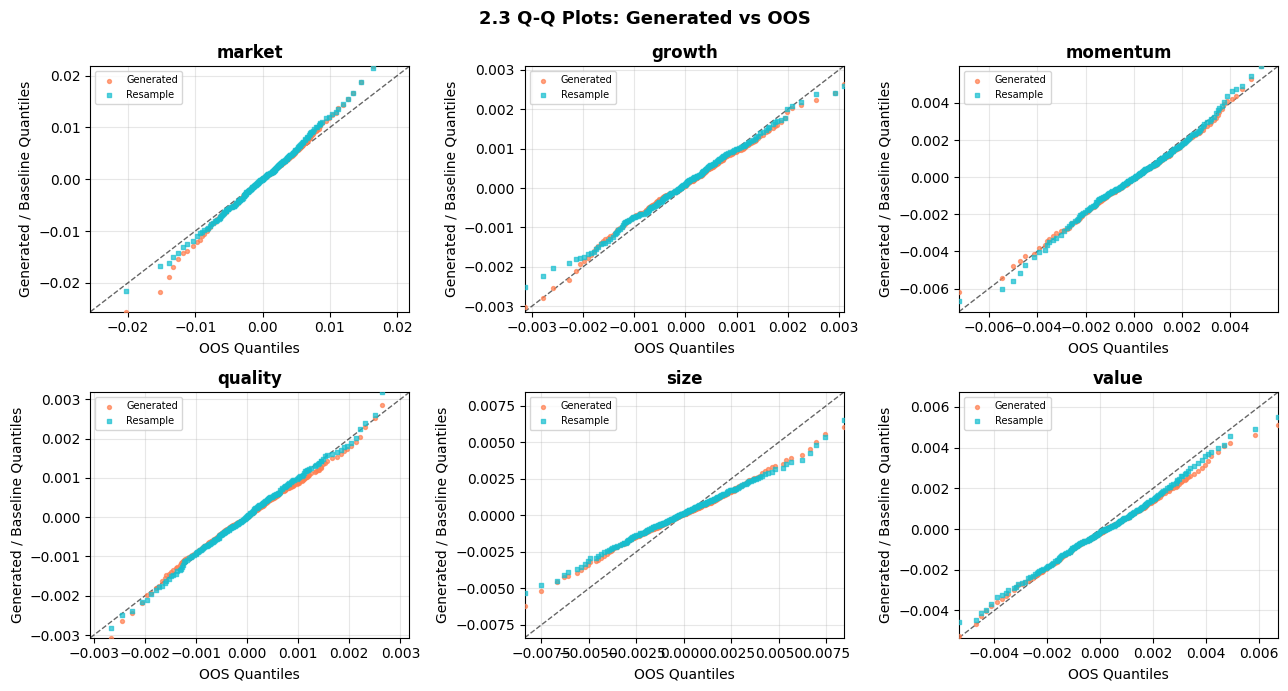

In [105]:
# 2.3 Quantile-Quantile (Q-Q) Plots
n_quantiles = 200
probs = np.linspace(0.01, 0.99, n_quantiles)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(len(FACTOR_NAMES))):
    q_OOS  = np.quantile(OOS[:, i],      probs)
    q_gen = np.quantile(sampled[:, i], probs)

    all_q = [q_OOS, q_gen] + [np.quantile(bdata[:, i], probs) for _, bdata in baselines]
    lim = [min(q.min() for q in all_q), max(q.max() for q in all_q)]

    ax.scatter(q_OOS, q_gen, s=8, color='coral', zorder=3, label='Generated', alpha=0.7)

    for (bname, bdata), bc in zip(baselines, base_colors):
        q_base = np.quantile(bdata[:, i], probs)
        ax.scatter(q_OOS, q_base, s=8, color=bc, zorder=3,
                   label=bname, alpha=0.7, marker='s')

    ax.plot(lim, lim, 'k--', lw=1, alpha=0.6)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('OOS Quantiles')
    ax.set_ylabel('Generated / Baseline Quantiles')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('2.3 Q-Q Plots: Generated vs OOS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [106]:
# 2.4 Kolmogorov-Smirnov Test
from scipy.stats import ks_2samp

D_THRESHOLD = 0.05
n_eff = len(OOS) * len(sampled) / (len(OOS) + len(sampled))

ks_gen   = [ks_2samp(OOS[:, i], sampled[:, i])[0] for i in range(len(FACTOR_NAMES))]
ks_bases = [(bname, [ks_2samp(OOS[:, i], bdata[:, i])[0]
                     for i in range(len(FACTOR_NAMES))])
            for bname, bdata in baselines]

def fmt(stat): return f"{stat:.4f} {'pass' if stat < D_THRESHOLD else 'FAIL'}"

col_w = 16
header = f"{'Factor':<18} {'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _ in ks_bases)
print(f"KS Stat (threshold D<{D_THRESHOLD})   n_eff={n_eff:.0f}")
print(header)
print("-" * len(header))
for j, name in enumerate(FACTOR_NAMES):
    row = f"{name:<18} {fmt(ks_gen[j]):<{col_w}}"
    for _, bks in ks_bases:
        row += f"{fmt(bks[j]):<{col_w}}"
    print(row)

KS Stat (threshold D<0.05)   n_eff=746
Factor             Generated       Resample        
---------------------------------------------------
market             0.0357 pass     0.0555 FAIL     
growth             0.0820 FAIL     0.0692 FAIL     
momentum           0.0570 FAIL     0.0465 pass     
quality            0.0424 pass     0.0315 pass     
size               0.1264 FAIL     0.1306 FAIL     
value              0.1115 FAIL     0.1013 FAIL     
volatility         0.0661 FAIL     0.0733 FAIL     


### Dimensionality Reduction

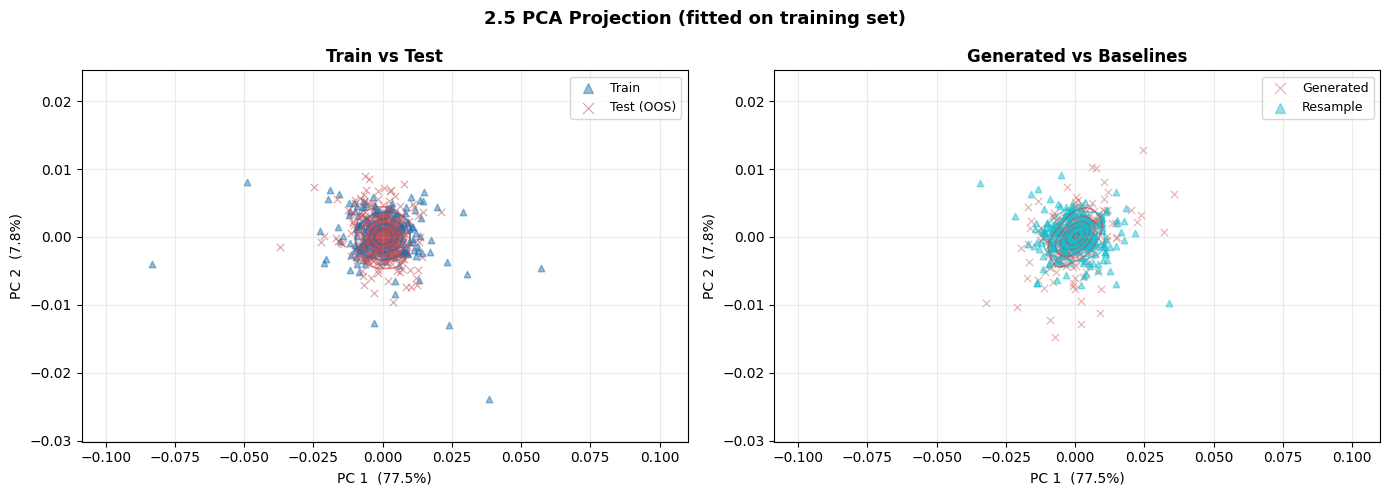

In [107]:
# 2.5 PCA Projection
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

pca = PCA(n_components=2)
pca.fit(train)

train_pc = pca.transform(train)
OOS_pc    = pca.transform(OOS)
gen_pc   = pca.transform(sampled)
base_pcs = [(bname, pca.transform(bdata)) for bname, bdata in baselines]

xlab = f"PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}%)"
ylab = f"PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}%)"

N_SUB   = 300
C1, C2  = '#1a6faf', '#c44e52'
MARKERS = ['^', 'P', 'D', 's']

def _sub(arr, n=N_SUB, seed=0):
    idx = np.random.default_rng(seed).choice(len(arr), size=min(n, len(arr)), replace=False)
    return arr[idx]

def _contour(ax, pc, color, levels=5, lw=1.2):
    kde  = gaussian_kde(pc.T)
    pad  = (pc.max(axis=0) - pc.min(axis=0)) * 0.15
    lo, hi = pc.min(axis=0) - pad, pc.max(axis=0) + pad
    xx, yy = np.mgrid[lo[0]:hi[0]:80j, lo[1]:hi[1]:80j]
    z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contour(xx, yy, z, levels=levels, colors=[color], alpha=0.65, linewidths=lw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Train (blue △) vs Test (crimson ×) ────────────────────────────────
_contour(ax1, train_pc, C1)
_contour(ax1, OOS_pc,    C2)
ax1.scatter(*_sub(train_pc, seed=0).T, c=C1, marker='^', s=22, alpha=0.45, label='Train')
ax1.scatter(*_sub(OOS_pc,    seed=1).T, c=C2, marker='x', s=28, alpha=0.55,
            label='Test (OOS)', linewidths=0.8)
ax1.set_xlabel(xlab); ax1.set_ylabel(ylab)
ax1.set_title('Train vs Test', fontweight='bold')
ax1.legend(fontsize=9, markerscale=1.5)
ax1.grid(True, alpha=0.25)

# ── Plot 2: Generated (crimson ×) vs Baselines (blue △ …) ────────────────────
_contour(ax2, gen_pc, C2)
ax2.scatter(*_sub(gen_pc, seed=0).T, c=C2, marker='x', s=28, alpha=0.45,
            label='Generated', linewidths=0.8)
for i, ((bname, bpc), bc) in enumerate(zip(base_pcs, base_colors)):
    _contour(ax2, bpc, bc)
    ax2.scatter(*_sub(bpc, seed=i+1).T, c=bc, marker=MARKERS[i % len(MARKERS)],
                s=22, alpha=0.45, label=bname)
ax2.set_xlabel(xlab); ax2.set_ylabel(ylab)
ax2.set_title('Generated vs Baselines', fontweight='bold')
ax2.legend(fontsize=9, markerscale=1.5)
ax2.grid(True, alpha=0.25)

fig.suptitle('2.5 PCA Projection (fitted on training set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [108]:
jupyter nbconvert --to webpdf evaluation.ipynb

SyntaxError: invalid syntax (2507530244.py, line 1)